<a href="https://colab.research.google.com/github/ohta-ee-ous/Lecture_ImageProcessing/blob/main/%E4%BD%93%E9%A8%93%E5%AD%A6%E7%BF%92_%E7%94%BB%E5%83%8F%E5%87%A6%E7%90%86%E3%82%92%E5%A7%8B%E3%82%81%E3%82%88%E3%81%86.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

---
<!--岡山理科大学 工学部 電気電子システム学科-->
<!--制作：太田寛志-ohta@ous.ac.jp-->

デジタル画像処理 体験学習

<h1>画像処理を始めよう</h1>

2026/05/04 改訂

---

# **はじめに**

画像処理は、コンピュータに「視覚」の力を与える技術です。スマホの顔認証や車の自動運転、製造ラインでの製品検査など、現代社会のあらゆる場所で重要な役割を担っています。本来、コンピュータにとって画像のデータは「各画素における明るさ情報の集合体」でしかありません。しかし、画像処理によってこの情報から対象の色や形を捉え、それが何であるのか認識できるようになります。

この体験学習では、画像処理を学ぶ第一歩として次の画像処理技術を体験します。
1. 画像の加工
1. 画像の変形
1. 画像の計測
1. 画像の照合
1. 画像の認識

# 学習の進め方

### ◼ 初めて学習する方へ

このファイルにあるコードは、Google Colaboratory で動作します。

このファイルを初めて開いたのならば、**まずは上のツールバーにある「ドライブにコピー」をクリックしてください。**
ファイルのコピーが、あなたの Google ドライブ内に保存されます。ファイル名は「体験学習_画像処理を始めよう.ipynbのコピー」になります。コピー元のファイルを書き換えることはできませんので、コピーしたファイルの方で学習を進めてください。

下記の「準備」を最初に行ってから、順序通りに進めてください。ソースコードが理解できなくても構いません。どんどん進めていってください。

### ◼ コードの実行方法は？

コードの実行は次の方法でできます。

［方法1］コードの上にマウスカーソルを持ってくるとコードの左上に ▶ が表示されるので、これをクリックする。

［方法2］コードが書かれているセルをクリックしてから Ctrl + Enter を入力する（Ctrlキーを押しながらEnterキーを押す）。

試しに、下のサンプルコードを実行してみてください。

初めて実行するときは実行環境の割り当ての処理が行われるため、実行が始まるまで少し時間がかかります。  
コードの下に「これはサンプルのコードです。」と表示されたら成功です。

In [ ]:
#@title ⌨ サンプルコード
print('これはサンプルのコードです。')

### ◼ 学習を途中から行うには？

このファイルの途中から始める場合や、学習を中断後再開する場合には、
まず下の準備のコードを実行して、その後、セクションの最初（1.～5.の番号がついている見出し）から始めてください。


### ◼ ファイルを初期状態に戻すには？

コードの実行結果だけをすべて消したい場合は、「編集」メニューから「出力をすべて消去」を行ってください。

ファイルをコピー直後の初期状態に戻したい場合は、「ファイル」メニューから「変更履歴」を表示して、**一番下**にあるバージョンのところの［︙］から「以前のバージョンを復元」を選んでください。

<a name="junbi"></a>
# **準備**

最初に、画像ファイルのダウンロードなどの準備を行います。次のコードを実行してください。

In [ ]:
#@title ⌨ 準備
# 外部モジュールを取り込む
import cv2
import numpy as np
import matplotlib.pyplot as plt
from google.colab import output
from google.colab.patches import cv2_imshow
from ipywidgets import interact, interactive, IntSlider, FloatSlider
from IPython.display import display

# ユーザーのディスプレイの解像度に合わせて画像の画面表示サイズを調整する
screen_resolution = output.eval_js('[window.screen.width, window.screen.height, screen.orientation.type]')
screen_scale = max(screen_resolution[:2])/1920
def show_image(img):
  if screen_scale >= 1.0:
    cv2_imshow(img)
  else:
    cv2_imshow(cv2.resize(img, None, fx=screen_scale, fy=screen_scale))

# 使用するデータをダウンロードする。
!wget -nc "https://github.com/ohta-ee-ous/Lecture_ImageProcessing/releases/download/v1.0.0/imageset.zip" -O imageset.zip
!unzip -nq imageset.zip
!rm -f imageset.zip
!if [[ -f "asagao.jpg" && -f "README.txt" ]]; then echo "準備が完了しました。"; else echo "ファイルが準備できませんでした。"; fi

「準備が完了しました。」と表示されたら次に進んでください。

<br>

# **1．画像の加工**

基礎的な画像処理として、画像を明るくする処理や、画像をぼかす処理などを行ってみましょう。

## 画像の読み込みと表示

まず、処理対象の画像をコンピュータに読み込ます。

ここでは、演習用に準備した「asagao.jpg」というファイル名の画像を読み込みます。次のコードを実行してください。

In [ ]:
#@title ⌨ 画像の入力
src = cv2.imread('asagao.jpg') # 画像を読み込む
if src is None:
  print('画像が読み込めませんでした。')
else:
  print('画像を読み込みました。')

「画像を読み込みました。」と表示されたら成功です。画像がコンピュータの中に記憶されました。

もし、「画像が読み込めませんでした。」と表示された場合は、「[準備](#junbi)」をやり直してください。

それでは、画面に画像を表示してみましょう。次のコードを実行してください。

In [ ]:
#@title ⌨ 画像の出力
show_image(src) # 画像を表示する

アサガオの花の写真が表示されれば成功です。

## 画像の明るさを変える

この画像を明るくしてみましょう。次のコードを実行してください。

In [ ]:
#@title ⌨ 輝度変換1
dst = src * 2.0 # dstに、srcの値を2倍した値を代入する
show_image(dst)

明るさを2倍にしてみましたが、ちょっと明るすぎでしょうか。

ちょうどいい明るさになるように、0倍から2倍までの範囲で明るさを変えてみましょう。  
次のコードを実行すると、明るさを調節するスライダーが画像の上側に表示されます。このスライダーのつまみ（○のマーク）を左右に動かして、明るさの変化を見てください。

In [ ]:
#@title ⌨ 輝度変換2
@interact(x=FloatSlider(min=0, max=2, step=0.1, value=1, description='明るさ倍率', continuous_update=False)) # 実数スライダ
def Brightness(x=1.0):
  dst = src * x
  show_image(dst)

画像データでは、画像の各点の明るさの度合いが数値化されています。
この値を指定した倍率の値に変えることによって、画像の明るさが変わるのです。

## 画像の彩度を変える

画像の色の鮮やかさのことを彩度と言います。彩度が高い画像は色がくっきりとしていて、見た目が派手です。逆に彩度が低いと色味がなくなり、灰色っぽくなります。

それでは画像の彩度の変換を行ってみましょう。次のコードを実行して、先ほどと同じようにスライダーを動かしてみてください。

In [ ]:
#@title ⌨ 彩度変換
hsv = cv2.cvtColor(src, cv2.COLOR_BGR2HSV_FULL)   # 色空間をRGBからHSVに変換
hue, sat, val = cv2.split(hsv)                    # 色相hue,彩度sat,明度valに分割

@interact(h=FloatSlider(min=0, max=2, step=0.2, value=1, description='彩度の倍率', continuous_update=False))
def transform_image(h):
  new_sat = np.clip(sat * h, 0, 255).astype('uint8')                           # 色相に値を加える
  dst = cv2.merge([hue, new_sat, val])            # 色相,彩度,明度を結合して一つの画像にする
  dst = cv2.cvtColor(dst, cv2.COLOR_HSV2BGR_FULL) # RGB色空間に変換
  show_image(dst)       # 左にdstの画像、右にsrcの画像を表示

彩度を高くすると、青色や緑色の色合いが強くなります。反対に、彩度を 0 にすると画像の色味が完全になくなってモノクロになります。

## 画像をぼかす

次は、画像にぼかし加工をしてみます。次のコードを実行してください。

In [ ]:
#@title ⌨ 平滑化
dst = cv2.medianBlur(src, 15) # メディアンフィルタ処理
show_image(dst)

花びらや葉っぱの表面がぼけて滑らかな感じになりましたね。ここでは、画像をぼかす働きがあるメディアンフィルタという処理を行っています。

ぼかす度合いは自由に変えられます。
次のコードを実行するとぼかしの度合いを調節するスライダーが表示されますので、画像の変化を見てください。

In [ ]:
#@title ⌨ 平滑化2
@interact(x=IntSlider(min=1, max=45, step=2, value=0, description='ぼかす度合い', continuous_update=False))
def MedianFilter(x=1):
  dst = cv2.medianBlur(src, x)
  show_image(dst)

花びらや葉っぱの表面はぼけますが、まわりの輪郭部分はあまりぼけていないことに気が付きましたか？
メディアンフィルタには、このように、色と色の境目の部分はぼかさずに残すという性質があります。

## 画像の鮮鋭化

今度は、逆に、画像を輪郭をはっきりとさせて鮮明にしてみましょう。  
次のコードを実行して、スライダーを動かしてみてください。

In [ ]:
#@title ⌨ 鮮鋭化
lap = cv2.Laplacian(src, cv2.CV_64F)
@interact(x=IntSlider(min=0, max=10, step=1, value=0, description='鮮鋭化の度合', continuous_update=False))
def Sharpening(x=1):
  dst = src - x*lap
  show_image(dst)

鮮鋭化の度合いが 0 のときが元の画像のままです。値を大きくすると、花びらや葉っぱの輪郭部分が明瞭になりますね。
ただし、あまり大きくしすぎると不自然な感じになりますので、適度な値に抑えておくことが必要です。

画像の加工を行う処理は他にもたくさんあります。それぞれの処理の性質を理解して、適切なものを選んで使うことが大切です。

## 画像の輪郭検出

別の加工も試しましょう。次のコードを実行してください。

In [ ]:
#@title ⌨ 輪郭検出
dst = 240 - cv2.Canny(src, 80, 130)/1.5 # キャニー法
show_image(dst)

線画のイラストのような画像ができました。ここでは、画像内の輪郭線を検出するキャニー法というものを利用しています。

輪郭線を検出するときに細かく検出するのか、あるいは、大雑把に検出するのかを数値で設定します。キャニー法では、2つのパラメータを使ってこの検出のしかたを調節します。

次のコードを実行するとパラメータを調節するスライダーが表示されます。スライダーを動かして輪郭線の検出が変化することを確かめてください。

In [ ]:
#@title ⌨ 輪郭検出2
def EdgeDetection(param1=80, param2=130):
  dst = 240 - cv2.Canny(src, param1, param2)/1.5
  show_image(dst)

p1 = IntSlider(min=0, max=200, step=1, value=80, continuous_update=False, description='パラメータ1')
p2 = IntSlider(min=0, max=200, step=1, value=130, continuous_update=False, description='パラメータ2')
ui = interactive(EdgeDetection, param1=p1, param2=p2)
display(ui)

## 画像を絵画風に変換

もっと高度で複雑な加工をしてみましょう。次のコードを実行してください。

In [ ]:
#@title ⌨ 非写実的レンダリング
dst = cv2.pencilSketch(src, sigma_s=5, sigma_r=0.08, shade_factor=0.05)
show_image(dst[1])

まるで絵画のような画像に加工できました。
いろいろな処理を組み合わせることによって、このような画像をつくることができます。

<br>

# **2．画像の変形**

スマートフォンで写真や地図を見るとき、細かいところよく見るために拡大したり、向きを変えるために回転させたりすることがありますよね。
このように写真の大きさを変えたりするときに使う画像の変形の処理について見ていきましょう。

## 画像の相似変換

まず、ここで使う画像を読み込みます。次のコードを実行してください。

In [ ]:
#@title ⌨ 画像入力
src = cv2.imread('bird.jpg')
if src is None:
  print('画像が読み込めませんでした。')
else:
  show_image(src)

鳥の画像が表示されれば成功です。

鳥がもっと見やすいように、画像を 2 倍に拡大してみましょう。次のコードを実行してください。

In [ ]:
#@title ⌨ 拡大縮小
x, y = src.shape[1]//2, src.shape[0]//2 # 画像の中心座標
mat = cv2.getRotationMatrix2D((x, y), 0, 2) # 変換行列を計算
dst = cv2.warpAffine(src, mat, None) # アフィン変換
show_image(dst)

画像の中央部分が拡大されました。画像の寸法（横幅と縦幅）は元のサイズのままであることに注意してください。

次は、元の画像を45°ななめに回転してみます。次のコードを実行してください。

In [ ]:
#@title ⌨ 回転
x, y = src.shape[1]//2, src.shape[0]//2 # 画像の中心座標
mat = cv2.getRotationMatrix2D((x, y), 45, 1) # 変換行列を計算
dst = cv2.warpAffine(src, mat, None) # アフィン変換
show_image(dst)

四隅に黒い領域が出てきましたが、これは元の画像にこの部分の色情報が無いためです。

では、拡大と回転と、さらに平行移動も同時に行ってみましょう。次のコードを実行してください。
スライダーで拡大率、回転角度、平行移動量を調節できます。  
最初の状態にリセットしたい場合は、実行し直してください。

In [ ]:
#@title ⌨ 相似変換
def SimilarityTransform(scale=1.0, angle=0, tx=0, ty=0):
  x, y = src.shape[1]//2, src.shape[0]//2
  m = cv2.getRotationMatrix2D((x, y), angle, scale)
  m[0,2] += tx
  m[1,2] += ty
  dst = cv2.warpAffine(src, m, None)
  show_image(dst)
scl = FloatSlider(min=0.5, max=2, step=0.1, value=1, continuous_update=False, description='拡大率')
ang = FloatSlider(min=-90, max=90, step=1, value=0, continuous_update=False, description='回転角度')
tx = IntSlider(min=-100, max=100, step=1, value=0, continuous_update=False, description='平行移動 横')
ty = IntSlider(min=-100, max=100, step=1, value=0, continuous_update=False, description='平行移動 縦')
ui = interactive(SimilarityTransform, scale=scl, angle=ang, tx=tx, ty=ty)
display(ui)

画像の拡大縮小、回転、平行移動の組み合わせでできる変形のことを相似変換と言います。

## 画像の射影変換

もっと複雑な変形をしてみましょう。次のコードを実行してください。

In [ ]:
#@title ⌨ 射影変換
mat = np.array([[1.22, 0.07, 77], [0.15, 0.63, -11], [2.22e-3, -1.32e-3, 1]])
dst = cv2.warpPerspective(src, mat, None)
show_image(dst)

画像の左側は大きく、右側は小さく変形しています。結果的に、画像が前後に傾いて奥行があるように感じられます。このように画像を変形することを射影変換と呼びます。

射影変換を利用すると次のようなことができます。コードを実行してください。

In [ ]:
#@title ⌨ イメージマッピング
w, h = src.shape[1::-1]
srcPoint = np.array([[0, 0], [w-1, 0], [w-1, h-1], [0, h-1]], np.float32) # 原画像の4隅の座標
dstPoint = np.array([[[245, 130], [412,  40], [400, 195], [275, 350]], # 直方体の頂点の座標
                     [  [75, 80], [245, 130], [275, 350], [135, 265]],
                     [  [75, 80], [280,  25], [412,  40], [245, 130]]], np.float32)
dst = np.full((h, w, 3), 160, np.float32)
for i in range(3):
  mat = cv2.getPerspectiveTransform(srcPoint, dstPoint[i]) # 射影変換行列を計算
  img = src.astype(np.float32)*(0.4*i**2+0.4) # 画像の明るさを変える
  cv2.warpPerspective(img, mat, None, dst, cv2.INTER_LINEAR, cv2.BORDER_TRANSPARENT) # 射影変換

show_image(dst)

直方体を斜めから見たような感じに見えますか？
直方体の面の位置に、射影変換で変形した画像を貼り付けることで、立体感が得られるようになります。

このように3Dモデルの面に画像を貼り付ける処理のことをマッピングと言います。
特に模様のパターンの画像を貼り付ける場合はテクスチャマッピングと言い、
3Dコンピュータグラフィックスでは基本となる処理です。

<br>

## 球面への変換

さらに複雑な変形として、球の表面にマッピングする変換をしてみます。次のコードを実行してください。

In [ ]:
#@title ⌨ 球面マッピング
radius = 140 # @param {"type":"slider", "min":40, "max":240, "step":1}
if isinstance(radius, int) is False or radius < 40 or radius > 240:
  radius = 140 # default
img = src.copy()
w, h = src.shape[1::-1]
cx, cy = w/2, h/2
img[40::40, :, :] = 200 # 格子の横線を描く
img[:, 40::40, :] = 200 # 格子の縦線を描く
dst = img.copy()
for y in range(h):
  for x in range(w):
    dx, dy = x-cx, y-cy
    distance = np.sqrt(dx**2+dy**2)
    if distance < radius:
      a = np.arctan2(dy, dx)
      r = np.asin(distance/radius)/np.pi*radius*2
      dst[y, x] = img[int(cy+r*np.sin(a)+.5), int(cx+r*np.cos(a)+.5)]
show_image(cv2.hconcat([dst, img])) # 変換後と変換前の画像を横に並べて表示

変換の結果が分かりやすいように、元の画像に格子模様を描き加えています。
右側の画像が変換前、左側の画像が変換後です。
画像中央部分が丸く膨らんでいるように見えますね。

コードの右側に表示されている「<tt>radius:</tt>」で球の半径が設定できます。値を 40 ～ 240 の範囲で好きに書き換えてからコードを実行してみてください。

<br>

# **3．画像の計測**

ここまでは、画像を元にして別の画像をつくってきました。ここからは、画像にどのようなものが写っているか解析していく処理を紹介します。

## 物体の個数を数える

使用する画像を読み込みます。次のコードを実行してください。

In [ ]:
#@title ⌨ 画像入力
src = cv2.imread('tangram.jpg')
if src is None:
  print('画像が読み込めませんでした。')
else:
  show_image(src)

これはタングラムと呼ばれるパズルのパーツの画像です。

今ここに物体は全部でいくつあるでしょうか？ コンピュータに数えさせてみましょう。ただし、くっついている２つのパーツは１つの物体としてかぞえます。
次のコードを実行してください。

In [ ]:
#@title ⌨ ラベリング処理
img = cv2.cvtColor(src, cv2.COLOR_BGR2GRAY) # グレイスケール変換
_, binary = cv2.threshold(img, 120, 255, cv2.THRESH_BINARY ) # 2値化
n, labels, stats, centroids = cv2.connectedComponentsWithStats(binary) # ラベリング
# ラベル番号で色を塗り分ける
labels = (labels % 256) * 255 // (n-1)
labels = labels.astype(np.uint8)
dst = cv2.applyColorMap(labels, cv2.COLORMAP_TURBO)
# ラベル番号を画像内に書く
for i in range(1, n):
  x, y = int(centroids[i][0]), int(centroids[i][1]) # 物体の中心座標
  cv2.putText(dst, str(i), (x-10, y+10), cv2.FONT_HERSHEY_SIMPLEX, 1, (0, 0, 0), 2, cv2.LINE_AA)
print(f'物体は {n-1} 個あります。')
show_image(dst)

物体ごとに色分けされて、番号がつけられています。最後の番号が 6 ですので、全部で 6個の物体が検出されました。

## 図形の頂点を数える

物体にはいろいろな形があります。次は、それぞれの物体を多角形の図形と見なして、図形の辺と頂点を検出してみましょう。
次のコードを実行してください。

In [ ]:
#@title ⌨ 輪郭追跡処理
contours, hierarchy = cv2.findContours(binary, cv2.RETR_EXTERNAL, cv2.CHAIN_APPROX_SIMPLE) # 輪郭追跡
# 輪郭の描画
dst = src.copy()
for a in contours:
  approx = cv2.approxPolyDP(a, 10, True) # 輪郭線を直線近似する
  cv2.polylines(dst, [approx], True, (80, 80, 255), 3, cv2.LINE_AA) # 輪郭線を描く
  m = cv2.moments(approx) # モーメント特徴量を計算
  x, y = int(m['m10']/m['m00']), int(m['m01']/m['m00']) # 物体の重心座標
  cv2.putText(dst, str(len(approx)), (x-10, y+10), cv2.FONT_HERSHEY_SIMPLEX, 0.8, (0,0,0), 2, cv2.LINE_AA) # 頂点の個数を物体の中央に表示
  for p in approx[:, 0, :]:
    cv2.circle(dst, p, 10, (80, 80, 255), -1, cv2.LINE_AA) # 頂点に円を描く
show_image(dst)

図形の頂点には○のマークが付けられ、辺には線分が描かれています。
図形の中の数字は、その図形の頂点の個数を示しています。

この結果から、それぞれの図形が、三角形とか四角形とか区別できます。
さらには、角の角度や辺の長さを測れば、図形が、正方形なのか、平行四辺形なのか、直角二等辺三角形なのか、細かく分類することもできますね。

## 図形の傾きを調べる

今度は、それぞれの物体の向きを調べてみましょう。次のコードを実行してください。

In [ ]:
#@title ⌨ 外接長方形検出
dst = src.copy()
for contour in contours:
  rect = cv2.minAreaRect(contour)  # 回転した外接長方形を求める
  x, y = int(rect[0][0]), int(rect[0][1]) # 物体の重心座標
  ang = -rect[2] if rect[1][0] > rect[1][1] else -90-rect[2]
  str = f"{ang:.1f}"
  w = cv2.getTextSize(str, cv2.FONT_HERSHEY_SIMPLEX, 0.6, 1)[0][0]//2
  cv2.putText(dst, str, (x-w, y+10), cv2.FONT_HERSHEY_SIMPLEX, 0.6, (0,0,0), 1, cv2.LINE_AA)
  box = cv2.boxPoints(rect)
  cv2.drawContours( dst, [np.intp(box)], 0, (80, 80, 255), 3, cv2.LINE_AA ) # 長方形を描く
  cv2.circle(dst, (x+w+5, y-2), 3, (0, 0, 0), 1, cv2.LINE_AA) # °
show_image(dst)

物体のまわりに長方形が描かれました。この長方形は外接長方形というもので、物体を取り囲む最小面積の長方形です。この長方形の傾き角度から、個々の物体の向きを測ることができます。
計測された角度がそれぞれの物体の上に表示されています。

## 円の検出

続いて、円の検出を行ってみましょう。次のコードを実行して新しい画像を読み込んでください。

In [ ]:
#@title ⌨ 画像の読み込み
src = cv2.imread('coins.jpg')
show_image(src)

先ほどのパズルのパーツの場合では、くっついているパーツはひとつの図形としていました。今回は物体がくっついたり重なったりしていても、それぞれの物体を分けて検出します。

次のコードを実行してください。

In [ ]:
#@title ⌨ 円の検出1
gray = cv2.cvtColor( src, cv2.COLOR_BGR2GRAY ) # グレイスケールに変換
circles = cv2.HoughCircles(gray, cv2.HOUGH_GRADIENT, dp=1, minDist=40, param1=60, param2=60, minRadius=30, maxRadius=80) # 円検出
dst = src.copy()
for x, y, r in circles[0]:
    cv2.circle( dst, (int(x), int(y)), int(r), (80, 80, 255), 3, cv2.LINE_AA) # 円を描く
print(f'円は {len(circles[0])} 個あります。')
show_image( dst )

すべての円が検出できました。ここでは、ハフ変換という図形検出法を使っています。
ハフ変換を使うと、物体同士が重なっている状態であってもそれぞれの図形を正確に検出できます。

円を検出した結果、それぞれの物体の半径が計測できています。次のコードを実行するとスライダーが表示されます。このスライダーで検出する円の最大半径を設定することができます。

In [ ]:
#@title ⌨ 円の検出2
@interact(r_max=IntSlider(min=30, max=80, step=1, value=0, description='最大半径'))
def Circle(r_max=30):
  dst = src.copy()
  for x, y, r in circles[0]:
      if r <= r_max:
        cv2.circle( dst, (int(x), int(y)), int(r), (80, 80, 255), 3, cv2.LINE_AA) # 円を描く
  show_image( dst )

<br>

# 4．画像の照合

画像の照合とは、２つの画像を照らし合わせて、どれだけ似ているかを調べる処理です。
この似ている度合いを類似度と言い、類似度が十分に高ければ、２つの画像は同じものとして識別されます。

## テンプレートマッチング

「探し物ゲーム」は、たくさんの物体が描かれているイラストの中から特定の一つの物体を見つけ出すパズルゲームです。

これと同じように、大小2つの画像があって、大きな画像の中のどこに小さな画像と同じものがあるのか探し出すということが画像処理でできます。
これをテンプレートマッチングと言い、小さな画像の方をテンプレート画像、大きな画像の方を対象画像と言います。

テンプレートマッチングを試してみましょう。まず、次のコードを実行して、テンプレート画像と対象画像を読み込んでください。

In [ ]:
#@title ⌨ 画像の読み込み
tp6 = cv2.imread('six.jpg')  # テンプレート画像
tgt = cv2.imread('cards.jpg') # 探索対象画像
print('テンプレート画像')
show_image(tp6)
print('\n対象画像')
show_image(tgt)

テンプレート画像は、数字の「６」が描かれているカードです。対象画像は、テンプレート画像のカードも含めて１４枚のカードが写っている画像です。

対象画像では、「６」のカードの一部分が隠れて見えていないことに注目してください。

では、テンプレートマッチングによって、テンプレート画像と同じカードが対象画像の中のどこにあるのか調べてみましょう。次のコードを実行してください。

In [ ]:
#@title ⌨ テンプレートマッチング
def TemplateMatching(target, template):
  s = cv2.matchTemplate(target, template, cv2.TM_CCOEFF_NORMED) # 正規化相互相関で類似を計算
  _, max, _, (x,y) = cv2.minMaxLoc(s) # 類似度最大の位置を取り出す
  h, w = template.shape[:2]
  dst = target.copy()
  cv2.rectangle(dst, (x, y), (x+w-1, y+h-1), (80, 255, 80), 5) # 四角形を描く
  show_image(dst)
  print(f'類似度は {max:.3f} です。')
TemplateMatching(tgt, tp6)

テンプレート画像と一致している部分が四角の枠線で示されています。カードの一部分が隠れてしまっていますが、ちゃんと「６」のカードが見つけられていますね。

画像の下に類似度の値も表示しています。類似度は、画像が完全に一致しているとき最大値の 1 になります。

今回はカードの一部が隠れてしまっているため、1 より小さな値になっています。

では、テンプレート画像を変えてみましょう。次のコードを実行してください。

In [ ]:
#@title ⌨ 画像の読み込み2
tp3 = cv2.imread('three.jpg')  # テンプレート画像
print('テンプレート画像')
show_image(tp3)

今度は「３」のカードですが、対象画像の中にはこれと同じ「３」のカードはありません。  
テンプレートマッチングを行うと結果はどうなるのでしょうか。次のコードを実行して確かめてください。

In [ ]:
#@title ⌨ テンプレートマッチング2
TemplateMatching(tgt, tp3)

テンプレートマッチングは最もよく似ている場所を見つけますので、「３」の絵柄に一番似ているカードが検出されています。

テンプレート画像と見比べてみてください。確かに絵柄が部分的に似ていますよね。

このように、画像が似ている度合いを計算によって求めて、画像の照合を行うことができます。

## 特徴点マッチング

テンプレートマッチングには、同じサイズで同じ向きでないと正しく照合できないという欠点があります。

次のコードを実行して、新しいテンプレート画像と対象画像を読み込んでください。

In [ ]:
#@title ⌨ 画像の読み込み3
img1 = cv2.imread( 'four.jpg')
img2 = cv2.imread( 'cards2.jpg' )
print('テンプレート画像')
show_image(img1)
print('\n対象画像')
show_image(img2)

それでは、この画像を使ってテンプレートマッチングした結果を見てみましょう。  
次のコードを実行してください。

In [ ]:
#@title ⌨ テンプレートマッチング3
TemplateMatching(img2, img1)

テンプレート画像のカードのサイズや向きが、対象画像内のカードと大きく違っているために、照合に失敗しています。

このような画像の照合では、テンプレートマッチングよりも特徴点マッチングの方が有効です。

特徴点とは、画像中で他の箇所と違いが明確にわかる特徴的な情報をもつ点のことです。画像内の物体の角（かど）の頂点などが特徴点となりえます。

同じ画像で特徴点マッチングを試してみましょう。次のコードを実行してください。

In [ ]:
#@title ⌨ 特徴点マッチング1
def FeaturePointMatching():
  global kp1, kp2, top_matches, dst, pad
  pad = 20
  detector = cv2.ORB_create()
  kp1, des1 = detector.detectAndCompute(img1, None)
  kp2, des2 = detector.detectAndCompute(img2, None)
  matcher = cv2.BFMatcher(cv2.NORM_HAMMING, crossCheck=True)
  matches = matcher.match(des1, des2)
  top_matches = sorted(matches, key=lambda x:x.distance)[:30]
  img1_pad = cv2.hconcat([img1, np.zeros((img1.shape[0], pad, 3), np.uint8)])
  dst = cv2.drawMatches(img1_pad, kp1, img2, kp2, top_matches, None, flags=0)
  show_image(dst)
FeaturePointMatching()

左側にクエリ画像（テンプレート画像）、右側に対象画像があります。特徴点マッチングでは、テンプレート画像とは呼ばすにクエリ画像と呼ぶことが多いです。

丸いマークで示されている場所が特徴点です。絵柄の角の部分に多く検出されていることがわかりますね。

この特徴点周辺の情報がよく似ている点同士の対応づける処理が特徴点マッチングです。上の結果では、対応する点を直線で結んで示しています。
ただし、正しい対応もあれば誤っている対応もあります。

特徴点の対応付けの結果から、正しい対応と思われるものだけを取り出してみましょう。

次のコードは、2つの画像を相似変換（平行移動・拡大・回転）で重ね合わせるという条件のもとで、正しいと思われる対応を見つけます。
コードを実行してください。

In [ ]:
#@title ⌨ ロバスト推定
def RobustEstimate(simi=True):
  global top_matches, dst2, M
  src_pts = np.float32([kp1[m.queryIdx].pt for m in top_matches]).reshape(-1, 1, 2)
  dst_pts = np.float32([kp2[m.trainIdx].pt for m in top_matches]).reshape(-1, 1, 2)
  if simi:
    M, m = cv2.estimateAffinePartial2D(src_pts, dst_pts)
  else:
    M, m = cv2.estimateAffine2D(src_pts, dst_pts)
  for i in range(len(m)-1, -1, -1):
    if m[i] == 0:
      top_matches.pop(i)
  img1_pad = cv2.hconcat([img1, np.zeros((img1.shape[0], pad, 3), np.uint8)])
  dst2 = cv2.drawMatches(img1_pad, kp1, img2, kp2, top_matches, None, flags=2)
  show_image(dst2)
RobustEstimate()

条件に合う対応だけが残りました。正しい対応の結果だけが得られていますね。

さらにこの結果から、クエリ画像と同じカードが対象画像のどこにあるのかを推定してみます。
次のコードを実行してください。

In [ ]:
#@title ⌨ 照合結果
def MatchingResult():
  h, w = img1.shape[:2]
  pts1 = np.array([[0, 0], [0, h-1], [w-1, h-1], [w-1, 0]]).reshape(-1, 1, 2)
  dst1_transformed = cv2.transform(pts1, M)+np.array([w+pad, 0])
  dst3 = dst2.copy()
  cv2.polylines(dst3, [np.int32(dst1_transformed)], True, (80, 255, 80), 10, cv2.LINE_AA)
  show_image(dst3)
MatchingResult()

このように、特徴点マッチングを利用すれば、2つの画像の間で物体のサイズや向きが違っていても正しく照合することができます。

対象画像を変えて試してみましょう。
次のコードを実行して新しい画像を読み込んでください。

In [ ]:
#@title ⌨ 画像の読み込み4
img2 = cv2.imread('cards3.jpg')
show_image(img2)

今度の対象画像はやや斜めから撮影されています。

次のコードを実行して、特徴点マッチングの結果を見てみましょう。

In [ ]:
#@title ⌨ 特徴点マッチング2
FeaturePointMatching()

続いて、正しい対応だけを検出します。次のコードを実行してください。

In [ ]:
#@title ⌨ ロバスト推定2
RobustEstimate(simi=False)

最後に、クエリ画像のカードがどこにあるのかを推定します。次のコードを実行してください。

In [ ]:
#@title ⌨ 照合結果2
MatchingResult()

位置が少しずれちゃっていますが、おおよそ正しい位置が得られています。

このように、特徴点がちゃんと見えてさえすれば照合を行うことが可能です。

<br>

# 5．画像の認識

最近のAI（人工知能）の進歩によって、画像認識の性能が飛躍的に向上しています。この画像認識について試していきましょう。

## 画像分類

画像分類は、画像に写っている物体の種類（クラス）を認識することです。
ここでは、次のコードに書かれている1000種類のうちのどれなのか、認識をしてみます。

まず、次のコードを実行して、1000種のクラスの名前を登録します。

In [ ]:
#@title ⌨ クラスの名前を登録
labels1k = ['tench', 'goldfish', 'great white shark', 'tiger shark', 'hammerhead', 'electric ray', 'stingray', 'cock', 'hen', 'ostrich', 'brambling', 'goldfinch', 'house finch', 'junco', 'indigo bunting', 'robin', 'bulbul', 'jay', 'magpie', 'chickadee', 'water ouzel', 'kite', 'bald eagle', 'vulture', 'great grey owl', 'European fire salamander', 'common newt', 'eft', 'spotted salamander', 'axolotl', 'bullfrog', 'tree frog', 'tailed frog', 'loggerhead', 'leatherback turtle', 'mud turtle', 'terrapin', 'box turtle', 'banded gecko', 'common iguana', 'American chameleon', 'whiptail', 'agama', 'frilled lizard', 'alligator lizard', 'Gila monster', 'green lizard', 'African chameleon', 'Komodo dragon', 'African crocodile', 'American alligator', 'triceratops', 'thunder snake', 'ringneck snake', 'hognose snake', 'green snake', 'king snake', 'garter snake', 'water snake', 'vine snake', 'night snake', 'boa constrictor', 'rock python', 'Indian cobra', 'green mamba', 'sea snake', 'horned viper', 'diamondback', 'sidewinder', 'trilobite', 'harvestman', 'scorpion', 'black and gold garden spider', 'barn spider', 'garden spider', 'black widow', 'tarantula', 'wolf spider', 'tick', 'centipede', 'black grouse', 'ptarmigan', 'ruffed grouse', 'prairie chicken', 'peacock', 'quail', 'partridge', 'African grey', 'macaw', 'sulphur-crested cockatoo', 'lorikeet', 'coucal', 'bee eater', 'hornbill', 'hummingbird', 'jacamar', 'toucan', 'drake', 'red-breasted merganser', 'goose', 'black swan', 'tusker', 'echidna', 'platypus', 'wallaby', 'koala', 'wombat', 'jellyfish', 'sea anemone', 'brain coral', 'flatworm', 'nematode', 'conch', 'snail', 'slug', 'sea slug', 'chiton', 'chambered nautilus', 'Dungeness crab', 'rock crab', 'fiddler crab', 'king crab', 'American lobster', 'spiny lobster', 'crayfish', 'hermit crab', 'isopod', 'white stork', 'black stork', 'spoonbill', 'flamingo', 'little blue heron', 'American egret', 'bittern', 'crane', 'limpkin', 'European gallinule', 'American coot', 'bustard', 'ruddy turnstone', 'red-backed sandpiper', 'redshank', 'dowitcher', 'oystercatcher', 'pelican', 'king penguin', 'albatross', 'grey whale', 'killer whale', 'dugong', 'sea lion', 'Chihuahua', 'Japanese spaniel', 'Maltese dog', 'Pekinese', 'Shih-Tzu', 'Blenheim spaniel', 'papillon', 'toy terrier', 'Rhodesian ridgeback', 'Afghan hound', 'basset', 'beagle', 'bloodhound', 'bluetick', 'black-and-tan coonhound', 'Walker hound', 'English foxhound', 'redbone', 'borzoi', 'Irish wolfhound', 'Italian greyhound', 'whippet', 'Ibizan hound', 'Norwegian elkhound', 'otterhound', 'Saluki', 'Scottish deerhound', 'Weimaraner', 'Staffordshire bullterrier', 'American Staffordshire terrier', 'Bedlington terrier', 'Border terrier', 'Kerry blue terrier', 'Irish terrier', 'Norfolk terrier', 'Norwich terrier', 'Yorkshire terrier', 'wire-haired fox terrier', 'Lakeland terrier', 'Sealyham terrier', 'Airedale', 'cairn', 'Australian terrier', 'Dandie Dinmont', 'Boston bull', 'miniature schnauzer', 'giant schnauzer', 'standard schnauzer', 'Scotch terrier', 'Tibetan terrier', 'silky terrier', 'soft-coated wheaten terrier', 'West Highland white terrier', 'Lhasa', 'flat-coated retriever', 'curly-coated retriever', 'golden retriever', 'Labrador retriever', 'Chesapeake Bay retriever', 'German short-haired pointer', 'vizsla', 'English setter', 'Irish setter', 'Gordon setter', 'Brittany spaniel', 'clumber', 'English springer', 'Welsh springer spaniel', 'cocker spaniel', 'Sussex spaniel', 'Irish water spaniel', 'kuvasz', 'schipperke', 'groenendael', 'malinois', 'briard', 'kelpie', 'komondor', 'Old English sheepdog', 'Shetland sheepdog', 'collie', 'Border collie', 'Bouvier des Flandres', 'Rottweiler', 'German shepherd', 'Doberman', 'miniature pinscher', 'Greater Swiss Mountain dog', 'Bernese mountain dog', 'Appenzeller', 'EntleBucher', 'boxer', 'bull mastiff', 'Tibetan mastiff', 'French bulldog', 'Great Dane', 'Saint Bernard', 'Eskimo dog', 'malamute', 'Siberian husky', 'dalmatian', 'affenpinscher', 'basenji', 'pug', 'Leonberg', 'Newfoundland', 'Great Pyrenees', 'Samoyed', 'Pomeranian', 'chow', 'keeshond', 'Brabancon griffon', 'Pembroke', 'Cardigan', 'toy poodle', 'miniature poodle', 'standard poodle', 'Mexican hairless', 'timber wolf', 'white wolf', 'red wolf', 'coyote', 'dingo', 'dhole', 'African hunting dog', 'hyena', 'red fox', 'kit fox', 'Arctic fox', 'grey fox', 'tabby', 'tiger cat', 'Persian cat', 'Siamese cat', 'Egyptian cat', 'cougar', 'lynx', 'leopard', 'snow leopard', 'jaguar', 'lion', 'tiger', 'cheetah', 'brown bear', 'American black bear', 'ice bear', 'sloth bear', 'mongoose', 'meerkat', 'tiger beetle', 'ladybug', 'ground beetle', 'long-horned beetle', 'leaf beetle', 'dung beetle', 'rhinoceros beetle', 'weevil', 'fly', 'bee', 'ant', 'grasshopper', 'cricket', 'walking stick', 'cockroach', 'mantis', 'cicada', 'leafhopper', 'lacewing', 'dragonfly', 'damselfly', 'admiral', 'ringlet', 'monarch', 'cabbage butterfly', 'sulphur butterfly', 'lycaenid', 'starfish', 'sea urchin', 'sea cucumber', 'wood rabbit', 'hare', 'Angora', 'hamster', 'porcupine', 'fox squirrel', 'marmot', 'beaver', 'guinea pig', 'sorrel', 'zebra', 'hog', 'wild boar', 'warthog', 'hippopotamus', 'ox', 'water buffalo', 'bison', 'ram', 'bighorn', 'ibex', 'hartebeest', 'impala', 'gazelle', 'Arabian camel', 'llama', 'weasel', 'mink', 'polecat', 'black-footed ferret', 'otter', 'skunk', 'badger', 'armadillo', 'three-toed sloth', 'orangutan', 'gorilla', 'chimpanzee', 'gibbon', 'siamang', 'guenon', 'patas', 'baboon', 'macaque', 'langur', 'colobus', 'proboscis monkey', 'marmoset', 'capuchin', 'howler monkey', 'titi', 'spider monkey', 'squirrel monkey', 'Madagascar cat', 'indri', 'Indian elephant', 'African elephant', 'lesser panda', 'giant panda', 'barracouta', 'eel', 'coho', 'rock beauty', 'anemone fish', 'sturgeon', 'gar', 'lionfish', 'puffer', 'abacus', 'abaya', 'academic gown', 'accordion', 'acoustic guitar', 'aircraft carrier', 'airliner', 'airship', 'altar', 'ambulance', 'amphibian', 'analog clock', 'apiary', 'apron', 'ashcan', 'assault rifle', 'backpack', 'bakery', 'balance beam', 'balloon', 'ballpoint', 'Band Aid', 'banjo', 'bannister', 'barbell', 'barber chair', 'barbershop', 'barn', 'barometer', 'barrel', 'barrow', 'baseball', 'basketball', 'bassinet', 'bassoon', 'bathing cap', 'bath towel', 'bathtub', 'beach wagon', 'beacon', 'beaker', 'bearskin', 'beer bottle', 'beer glass', 'bell cote', 'bib', 'bicycle-built-for-two', 'bikini', 'binder', 'binoculars', 'birdhouse', 'boathouse', 'bobsled', 'bolo tie', 'bonnet', 'bookcase', 'bookshop', 'bottlecap', 'bow', 'bow tie', 'brass', 'brassiere', 'breakwater', 'breastplate', 'broom', 'bucket', 'buckle', 'bulletproof vest', 'bullet train', 'butcher shop', 'cab', 'caldron', 'candle', 'cannon', 'canoe', 'can opener', 'cardigan', 'car mirror', 'carousel', 'carpenters kit', 'carton', 'car wheel', 'cash machine', 'cassette', 'cassette player', 'castle', 'catamaran', 'CD player', 'cello', 'cellular telephone', 'chain', 'chainlink fence', 'chain mail', 'chain saw', 'chest', 'chiffonier', 'chime', 'china cabinet', 'Christmas stocking', 'church', 'cinema', 'cleaver', 'cliff dwelling', 'cloak', 'clog', 'cocktail shaker', 'coffee mug', 'coffeepot', 'coil', 'combination lock', 'computer keyboard', 'confectionery', 'container ship', 'convertible', 'corkscrew', 'cornet', 'cowboy boot', 'cowboy hat', 'cradle', 'crane', 'crash helmet', 'crate', 'crib', 'Crock Pot', 'croquet ball', 'crutch', 'cuirass', 'dam', 'desk', 'desktop computer', 'dial telephone', 'diaper', 'digital clock', 'digital watch', 'dining table', 'dishrag', 'dishwasher', 'disk brake', 'dock', 'dogsled', 'dome', 'doormat', 'drilling platform', 'drum', 'drumstick', 'dumbbell', 'Dutch oven', 'electric fan', 'electric guitar', 'electric locomotive', 'entertainment center', 'envelope', 'espresso maker', 'face powder', 'feather boa', 'file', 'fireboat', 'fire engine', 'fire screen', 'flagpole', 'flute', 'folding chair', 'football helmet', 'forklift', 'fountain', 'fountain pen', 'four-poster', 'freight car', 'French horn', 'frying pan', 'fur coat', 'garbage truck', 'gasmask', 'gas pump', 'goblet', 'go-kart', 'golf ball', 'golfcart', 'gondola', 'gong', 'gown', 'grand piano', 'greenhouse', 'grille', 'grocery store', 'guillotine', 'hair slide', 'hair spray', 'half track', 'hammer', 'hamper', 'hand blower', 'hand-held computer', 'handkerchief', 'hard disc', 'harmonica', 'harp', 'harvester', 'hatchet', 'holster', 'home theater', 'honeycomb', 'hook', 'hoopskirt', 'horizontal bar', 'horse cart', 'hourglass', 'iPod', 'iron', 'jack-o-lantern', 'jean', 'jeep', 'jersey', 'jigsaw puzzle', 'jinrikisha', 'joystick', 'kimono', 'knee pad', 'knot', 'lab coat', 'ladle', 'lampshade', 'laptop', 'lawn mower', 'lens cap', 'letter opener', 'library', 'lifeboat', 'lighter', 'limousine', 'liner', 'lipstick', 'Loafer', 'lotion', 'loudspeaker', 'loupe', 'lumbermill', 'magnetic compass', 'mailbag', 'mailbox', 'maillot', 'maillot', 'manhole cover', 'maraca', 'marimba', 'mask', 'matchstick', 'maypole', 'maze', 'measuring cup', 'medicine chest', 'megalith', 'microphone', 'microwave', 'military uniform', 'milk can', 'minibus', 'miniskirt', 'minivan', 'missile', 'mitten', 'mixing bowl', 'mobile home', 'Model T', 'modem', 'monastery', 'monitor', 'moped', 'mortar', 'mortarboard', 'mosque', 'mosquito net', 'motor scooter', 'mountain bike', 'mountain tent', 'mouse', 'mousetrap', 'moving van', 'muzzle', 'nail', 'neck brace', 'necklace', 'nipple', 'notebook', 'obelisk', 'oboe', 'ocarina', 'odometer', 'oil filter', 'organ', 'oscilloscope', 'overskirt', 'oxcart', 'oxygen mask', 'packet', 'paddle', 'paddlewheel', 'padlock', 'paintbrush', 'pajama', 'palace', 'panpipe', 'paper towel', 'parachute', 'parallel bars', 'park bench', 'parking meter', 'passenger car', 'patio', 'pay-phone', 'pedestal', 'pencil box', 'pencil sharpener', 'perfume', 'Petri dish', 'photocopier', 'pick', 'pickelhaube', 'picket fence', 'pickup', 'pier', 'piggy bank', 'pill bottle', 'pillow', 'ping-pong ball', 'pinwheel', 'pirate', 'pitcher', 'plane', 'planetarium', 'plastic bag', 'plate rack', 'plow', 'plunger', 'Polaroid camera', 'pole', 'police van', 'poncho', 'pool table', 'pop bottle', 'pot', 'potters wheel', 'power drill', 'prayer rug', 'printer', 'prison', 'projectile', 'projector', 'puck', 'punching bag', 'purse', 'quill', 'quilt', 'racer', 'racket', 'radiator', 'radio', 'radio telescope', 'rain barrel', 'recreational vehicle', 'reel', 'reflex camera', 'refrigerator', 'remote control', 'restaurant', 'revolver', 'rifle', 'rocking chair', 'rotisserie', 'rubber eraser', 'rugby ball', 'rule', 'running shoe', 'safe', 'safety pin', 'saltshaker', 'sandal', 'sarong', 'sax', 'scabbard', 'scale', 'school bus', 'schooner', 'scoreboard', 'screen', 'screw', 'screwdriver', 'seat belt', 'sewing machine', 'shield', 'shoe shop', 'shoji', 'shopping basket', 'shopping cart', 'shovel', 'shower cap', 'shower curtain', 'ski', 'ski mask', 'sleeping bag', 'slide rule', 'sliding door', 'slot', 'snorkel', 'snowmobile', 'snowplow', 'soap dispenser', 'soccer ball', 'sock', 'solar dish', 'sombrero', 'soup bowl', 'space bar', 'space heater', 'space shuttle', 'spatula', 'speedboat', 'spider web', 'spindle', 'sports car', 'spotlight', 'stage', 'steam locomotive', 'steel arch bridge', 'steel drum', 'stethoscope', 'stole', 'stone wall', 'stopwatch', 'stove', 'strainer', 'streetcar', 'stretcher', 'studio couch', 'stupa', 'submarine', 'suit', 'sundial', 'sunglass', 'sunglasses', 'sunscreen', 'suspension bridge', 'swab', 'sweatshirt', 'swimming trunks', 'swing', 'switch', 'syringe', 'table lamp', 'tank', 'tape player', 'teapot', 'teddy', 'television', 'tennis ball', 'thatch', 'theater curtain', 'thimble', 'thresher', 'throne', 'tile roof', 'toaster', 'tobacco shop', 'toilet seat', 'torch', 'totem pole', 'tow truck', 'toyshop', 'tractor', 'trailer truck', 'tray', 'trench coat', 'tricycle', 'trimaran', 'tripod', 'triumphal arch', 'trolleybus', 'trombone', 'tub', 'turnstile', 'typewriter keyboard', 'umbrella', 'unicycle', 'upright', 'vacuum', 'vase', 'vault', 'velvet', 'vending machine', 'vestment', 'viaduct', 'violin', 'volleyball', 'waffle iron', 'wall clock', 'wallet', 'wardrobe', 'warplane', 'washbasin', 'washer', 'water bottle', 'water jug', 'water tower', 'whiskey jug', 'whistle', 'wig', 'window screen', 'window shade', 'Windsor tie', 'wine bottle', 'wing', 'wok', 'wooden spoon', 'wool', 'worm fence', 'wreck', 'yawl', 'yurt', 'web site', 'comic book', 'crossword puzzle', 'street sign', 'traffic light', 'book jacket', 'menu', 'plate', 'guacamole', 'consomme', 'hot pot', 'trifle', 'ice cream', 'ice lolly', 'French loaf', 'bagel', 'pretzel', 'cheeseburger', 'hotdog', 'mashed potato', 'head cabbage', 'broccoli', 'cauliflower', 'zucchini', 'spaghetti squash', 'acorn squash', 'butternut squash', 'cucumber', 'artichoke', 'bell pepper', 'cardoon', 'mushroom', 'Granny Smith', 'strawberry', 'orange', 'lemon', 'fig', 'pineapple', 'banana', 'jackfruit', 'custard apple', 'pomegranate', 'hay', 'carbonara', 'chocolate sauce', 'dough', 'meat loaf', 'pizza', 'potpie', 'burrito', 'red wine', 'espresso', 'cup', 'eggnog', 'alp', 'bubble', 'cliff', 'coral reef', 'geyser', 'lakeside', 'promontory', 'sandbar', 'seashore', 'valley', 'volcano', 'ballplayer', 'groom', 'scuba diver', 'rapeseed', 'daisy', 'yellow ladys slipper', 'corn', 'acorn', 'hip', 'buckeye', 'coral fungus', 'agaric', 'gyromitra', 'stinkhorn', 'earthstar', 'hen-of-the-woods', 'bolete', 'ear', 'toilet tissue']
print(f'{len(labels1k)}個のクラスを登録しました。')

「1000個のクラスを登録しました。」と表示されたら次に進んでください。

次に画像分類に使用するデータを別のWebサイトからダウンロードしてコンピュータに読み込ます。

次のコードを実行してください。

In [ ]:
#@title ⌨ MobileNetV2
#https://github.com/opencv/opencv_zoo
!wget -nc -O mobilenetv2.onnx https://github.com/opencv/opencv_zoo/raw/refs/heads/main/models/image_classification_mobilenet/image_classification_mobilenetv2_2022apr.onnx
!if [ -f "mobilenetv2.onnx" ]; then echo "準備が完了しました。"; else echo "ファイルが準備できませんでした。"; fi
# モデルの設定
model_cl = cv2.dnn.ClassificationModel('mobilenetv2.onnx')
model_cl.setInputParams(1/255, (224, 224), [0.485, 0.456, 0.406], True, False)

# クラス分類を実行する関数
def classification(model, image):
  conf = model.predict(image)       # クラス推定
  conf = np.squeeze(conf[0])
  e = np.exp(conf-np.max(conf))
  conf = e/np.sum(e)                # 推定確率を計算（Softmax）
  list = np.argsort(conf)[-1:-4:-1] # 確率が高い上位3つを取り出す
  print(f'これは、{labels1k[list[0]]}（クラス番号 {list[0]}）の画像です。')
  for i, id in enumerate(list):
    print(f'{i+1} {labels1k[id]} --- {conf[id]*100:.1f}%') # 結果の表示

「準備が完了しました。」と表示されたら次に進んでください。

コンピュータに認識させる画像を読み込みます。次のコードを実行してください。

In [ ]:
#@title ⌨ 画像入力
src = cv2.imread('guitar.jpg')
show_image(src)

それでは、これが何であるのかをコンピュータに答えてもらいます。次のコードを実行してください。

In [ ]:
#@title ⌨ クラス分類
classification(model_cl, src) # クラス分類を実行

コンピュータが推定したクラスの名前が表示されます。また、推定確率（推定の確実さ）が高い順にクラスを3つまで表示しています。

結果を見ると、acoustic guitar（アコースティックギター）が推定確率 93.0% という高い確率で推定できています。他の可能性として、electric guitar（エレキギター）6.3% という結果も出ています。

別の画像を試してみましょう。次のコードを実行して画像を読み込んでください。

In [ ]:
#@title ⌨ 画像入力2
src = cv2.imread('mycat.jpg') # 画像ファイルを読み込む
show_image(src)

続いて、次のコードを実行して推定結果を見てください。

In [ ]:
#@title ⌨ クラス分類2
classification(model_cl, src) # クラス分類を実行

確率が高い順に、lynx（オオヤマネコ）、Persian cat（ペルシャネコ）、tiger cat（タイガーキャット、ジャガーネコ）となりました。

写真の猫は雑種ですから猫種の推定は難しいようですね。ともかく、猫としては正しく認識できています。

今度はあなたが持っている画像で試してみましょう。まず、適当な画像ファイルを用意してください。ただし、上の「クラスの名前を登録」のコードの中に書かれているものしか認識できませんので注意してください。  
次に下のコードを実行すると「ファイル選択」のボタンが表示されます。これをクリックして画像ファイルを指定してください。画像ファイルがColabにアップロードされると、クラス分類が行われます。

In [ ]:
#@title ⌨ アップロードした画像ファイルのクラス分類
from google.colab import files
uploaded = files.upload(); # ファイルのアップロード
if uploaded:
  img = cv2.imdecode(np.frombuffer(list(uploaded.values())[0], np.uint8), cv2.IMREAD_COLOR)
  if img.shape[1] > 480:
    img = cv2.resize(img, None, fx=480/img.shape[1], fy=480/img.shape[1])
  show_image(img)
  classification(model_cl, img)
else:
  print('ファイルが読み込まれませんでした。')

うまく認識されましたか？
認識を誤る場合もよくありますので、画像を替えてみてどのような画像が正しく認識されやすいのか、いろいろ試してみてください。

## 一般物体認識

先ほどの画像分類では、画像からクラスを一つ推定しました。

しかし、画像に異なる物体がいくつも写っている場合は、画像のどの位置に何の物体が写っているのかを一つ一つ認識する必要があります。これを一般物体認識と言います。

この一般物体認識を試してみましょう。まず、画像認識のための準備をしますので、次のコードを実行してください。

In [ ]:
#@title ⌨ 一般物体認識の準備
!wget -nc https://github.com/AlexeyAB/darknet/releases/download/yolov4/yolov7.weights
!wget -nc https://raw.githubusercontent.com/AlexeyAB/darknet/master/cfg/yolov7.cfg
model = cv2.dnn.DetectionModel('yolov7.weights', 'yolov7.cfg')

# 一般物体認識のクラスの登録
labels_coco = ['person', 'bicycle', 'car', 'motorbike', 'aeroplane', 'bus', 'train', 'truck', 'boat', 'traffic light', 'fire hydrant', 'stop sign', 'parking meter', 'bench', 'bird', 'cat', 'dog', 'horse', 'sheep', 'cow', 'elephant', 'bear', 'zebra', 'giraffe', 'backpack', 'umbrella', 'handbag', 'tie', 'suitcase', 'frisbee', 'skis', 'snowboard', 'sports ball', 'kite', 'baseball bat', 'baseball glove', 'skateboard', 'surfboard', 'tennis racket', 'bottle', 'wine glass', 'cup', 'fork', 'knife', 'spoon', 'bowl', 'banana', 'apple', 'sandwich', 'orange', 'broccoli', 'carrot', 'hot dog', 'pizza', 'donut', 'cake', 'chair', 'sofa', 'pottedplant', 'bed', 'diningtable', 'toilet', 'tvmonitor', 'laptop', 'mouse', 'remote', 'keyboard', 'cell phone', 'microwave', 'oven', 'toaster', 'sink', 'refrigerator', 'book', 'clock', 'vase', 'scissors', 'teddy bear', 'hair drier', 'toothbrush']
print(len(labels_coco),'個のクラスを登録しました。')

!if [[ -f "yolov7.weights" && -f "yolov7.cfg" ]]; then echo "準備が完了しました。"; else echo "ファイルが準備できませんでした。"; fi

実行してしばらく待つとメッセージが表示されます。メッセージの最後に「準備が完了しました。」と表示されていれば成功です。  
今回認識できる物体は、コードの中に書かれている80種類です。

コンピュータに認識させたい画像を用意します。
次のコードを実行してください。

In [ ]:
#@title ⌨ 画像の読み込み
src = cv2.imread('desktop.jpg')
show_image(src)

では、この画像に何が写っているのか、コンピュータに答えてもらいましょう。

次のコードを実行してください。計算量が多いので、結果が出るまで少し時間がかかります。

In [ ]:
#@title ⌨ 一般物体認識
def drawObjectName(src, classids, confs, boxes, th=0.5):
  dst = src.copy()
  color = []
  np.random.seed(0)
  for box, conf in zip(boxes, confs):
    c = np.random.randint(0, 221, 3).tolist()
    color.append(c)
    if conf >= th:
      cv2.rectangle(dst, box, c, int(conf*3+1), cv2.LINE_AA)
  for i, (id, conf, box) in enumerate(zip(class_ids, confs, boxes)):
    if conf >= th:
      name = labels_coco[id]
      point = np.array([box[0]+2, box[1]+20])
      w = cv2.getTextSize(name, cv2.FONT_HERSHEY_SIMPLEX, 0.8, 6)[0][0]
      if point[0] + w >= dst.shape[1]:
        point[0] = dst.shape[1] - w
      cv2.putText(dst, name, point, cv2.FONT_HERSHEY_SIMPLEX, 0.8, color[i], 6, cv2.LINE_AA)
      cv2.putText(dst, name, point, cv2.FONT_HERSHEY_SIMPLEX, 0.8, (255,255,255), 2, cv2.LINE_AA)
  return dst

# モデルの設定
model.setInputParams(scale=1/255, size=(640, 640), swapRB=True, crop=False)
# 物体検出を行う
class_ids, confs, boxes = model.detect(src, confThreshold=0.0, nmsThreshold=0.5)
dst = drawObjectName(src, class_ids, confs, boxes)
show_image(dst)

キーボード（keyboard）、マウス（mouse）、コップ（cup）、はさみ（scissors）、携帯電話（cell phone）の名前が表示されました。また、それぞれの物体が画像のどこにあるのかが四角の枠線で示されています。どれも正しく認識できていますね。

それでは、ほかの画像でも試してみましょう。
次のコードを実行して、別の画像を読み込んでください。

In [ ]:
#@title ⌨ 画像の読み込み2
src = cv2.imread('play.jpg')
show_image(cv2.resize(src, (480, 480))) # サイズを縮小して表示

この画像は生成AIで作ったみたものです。
先ほどと同じようにコンピュータに認識させてみましょう。

次のコードを実行してください。
実行結果が出てくるまで、少し時間がかかります。

In [ ]:
#@title ⌨ 一般物体認識2
class_ids, confs, boxes = model.detect(src, confThreshold=0.6, nmsThreshold=0.5)
dst = drawObjectName(src, class_ids, confs, boxes, 0.6)
show_image(cv2.resize(dst, (480, 480))) # サイズを縮小して表示する

次のものが認識されています。

人（person）、犬（dog）、猫（cat）、鳥（bird）、鉢植え（pottedplant）、花瓶（vase）、時計（clock）、ソファ（sofa）、本（book）、車（car）、バス（bus）、トラック（truck）

犬や猫にはいろいろな種類がいるのに、ちゃんと見分けられていますね。また、人も服装や髪型、姿勢などいろいろなバリエーションがあって複雑なのに、人として正しく認識できていますね。

検出したそれぞれのものには、推測確率という値（0～1の範囲）があります。
コンピュータが確実だと思っているものほど、推定確率が大きくなっています。
上の結果では、推定確率が0.6以上のものだけを表示しています。

表示する推定確率の最小値を変えてみましょう。
次のコードを実行するとスライダーが表示されます。このスライダーで表示する推定確率の最小値が変えられます。

In [ ]:
#@title ⌨ 一般物体認識3
model.setInputParams(scale=1/255, size=(800, 800), swapRB=True)
class_ids, confs, boxes = model.detect(src, confThreshold=0.0, nmsThreshold=0.5)
@interact(x=FloatSlider(min=0.0, max=1.0, step=0.05, value=0.6, description='推定確率'))
def recognitionResult(x=0.5):
  dst = drawObjectName(src, class_ids, confs, boxes, x)
  show_image(cv2.resize(dst, (480, 480)))


推定確率を小さくするほど表示される物体の数が増えますが、認識結果が間違っているものが出てきますね。  
判定に推定確率を大きくするほど表示される物体が減りますが、確実であるものだけが残ります。

このように、画像認識の性能は、AI技術の発展によって人間と同じくらいのレベルにまで進歩してきています。

最後に、あなたが持っている画像で試してみましょう。適当な画像ファイルを用意してください。  
次に下のコードを実行すると「ファイル選択」のボタンが表示されます。これをクリックして画像ファイルを指定してください。画像ファイルがColabにアップロードされると、物体認識が行われます。

In [ ]:
#@title ⌨ アップロードした画像ファイルで物体認識
from google.colab import files
uploaded = files.upload(); # ファイルのアップロード
if uploaded:
  img = cv2.imdecode(np.frombuffer(list(uploaded.values())[0], np.uint8), cv2.IMREAD_COLOR)
  if img.shape[1] > 600:
    img = cv2.resize(img, None, fx=600/img.shape[1], fy=600/img.shape[1])
  class_ids, confs, boxes = model.detect(img, confThreshold=0.6, nmsThreshold=0.5)
  dst = drawObjectName(img, class_ids, confs, boxes, 0.6)
  show_image(dst)
else:
  print('ファイルが読み込まれませんでした。')

うまく認識できましたか？ いろいろと画像を替えてみてください。

<br>

# 最後に

以上で体験学習は終了です。画像処理とはどういうものか理解していただけたでしょうか。

この学習によって画像処理の分野に興味をもってもらえたら嬉しいです。

<!-- Copyright (C) 2025 OHTA Hiroshi -->

---
Copyright © 2026 OHTA Hiroshi @ Okayama University of Science  
<small>岡山理科大学 工学部 電気電子システム学科 太田研究室</small>

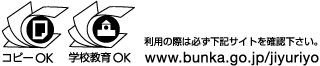  
このipynbファイルは、学校教育のための非営利目的利用を認めます。[https://www.bunka.go.jp/jiyuriyo](https://www.bunka.go.jp/jiyuriyo)  
この体験学習で使用している画像ファイル（imageset.zip、及び、imageset.zip 内の個々のファイル）については再配布を禁止します。